# Lab 2 Alzheimer's Disease Classification with CNNs (TensorFlow / Keras)

**Course:** AI for Diagnosis of Neurodegenerative Diseases Â· Session 4

Dr. Alejandro Santos DÃ­az,
TecnolÃ³gico de Monterrey

**Goal:** Build and train a **convolutional neural network *from scratch* (a "vanilla" CNN)** to distinguish
**Alzheimer's disease (AD) from healthy controls (HC)** on a public MRI image dataset, evaluate it
rigorously, and interpret its decisions with **Grad-CAM**.

In the guided lab we deliberately train a CNN with **randomly initialized weights** (no pretraining), so you
see what a convolutional network can learn end-to-end from the images alone. In the **homework** you will then
measure how much **transfer learning** helps by comparing **two pretrained architectures**.

---

### Learning objectives
1. Build an efficient `tf.data` input pipeline for medical images.
2. **Design and train a CNN from scratch** (convolutional + pooling + dense layers) with data augmentation.
3. Train with the Keras `fit()` API using callbacks (early stopping + best-checkpoint restore) and GPU acceleration.
4. Evaluate a CNN with accuracy, balanced accuracy, ROC-AUC and confusion matrices.
5. Use **Grad-CAM** to visualize where the model looks a first step to clinical trust.

### Prerequisites
- The theory from **Session 3** (CNNs, convolution/pooling, transfer learning, Grad-CAM).
- Basic Keras (`Sequential`/functional API, `compile`, `fit`). The notebook recaps the essentials.

### Runtime â€” IMPORTANT: enable GPU
In Colab: **Runtime â†’ Change runtime type T4 GPU**. Training a CNN on CPU is possible but slow.

Estimated time: **60-90 min** on a Colab GPU (use **Quick mode** for a faster first pass).

> **Disclaimer.** Educational prototype on a small public image set. **Not** a clinical diagnostic tool.

## 1. Setup

Colab already ships **TensorFlow** (with Keras) and the utilities we need. We only add the HuggingFace
`datasets` library to download the dataset.

In [ ]:
# Colab already ships tensorflow/keras; we add the HF datasets library.
!pip install -q datasets

import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report, RocCurveDisplay)

sns.set_theme(style="whitegrid", palette="muted")

# GPU check â€” TensorFlow uses the GPU automatically if one is visible.
gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow", tf.__version__, "| GPUs:", gpus if gpus else "none (using CPU)")

SEED = 42
keras.utils.set_random_seed(SEED)   # makes shuffles/splits/inits reproducible

TensorFlow 2.20.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. The dataset

We use the publicly available **Alzheimer MRI** dataset (4 classes) hosted on HuggingFace no account
or API key required (`Falah/Alzheimer_MRI`):

- **6,400 brain MRI images** (128Ã—128, grayscale): 5,120 train + 1,280 test.
- 4 classes: `0` Mild, `1` Moderate, `2` Non_Demented (healthy), `3` Very Mild.
- In this lab we collapse it to a **binary AD vs HC** problem:
  `Non_Demented (2) â†’ HC`, everything else`AD`.

**Source / license:** [HuggingFace `Falah/Alzheimer_MRI`](https://huggingface.co/datasets/Falah/Alzheimer_MRI).
Originally derived from the Kaggle "Alzheimer's Dataset (4 class of Images)".

In [ ]:
hf = load_dataset("Falah/Alzheimer_MRI")
print(hf)
label_names = {0: "Mild", 1: "Moderate", 2: "Non (HC)", 3: "Very Mild"}

for split in hf:
    print(split, "n =", len(hf[split]), "| label dist:", dict(collections.Counter(hf[split]["label"])))

README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…): reconstructing file:   0%|          |  0.00B / 22.6MB            

data/train-00000-of-00001-c08a401c53fe53(…): downloading bytes:           |  0.00B            

data/test-00000-of-00001-44110b9df98c558(…): reconstructing file:   0%|          |  0.00B / 5.65MB            

data/test-00000-of-00001-44110b9df98c558(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 5120
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 1280
    })
})
train n = 5120 | label dist: {2: 2566, 0: 724, 3: 1781, 1: 49}
test n = 1280 | label dist: {3: 459, 0: 172, 2: 634, 1: 15}


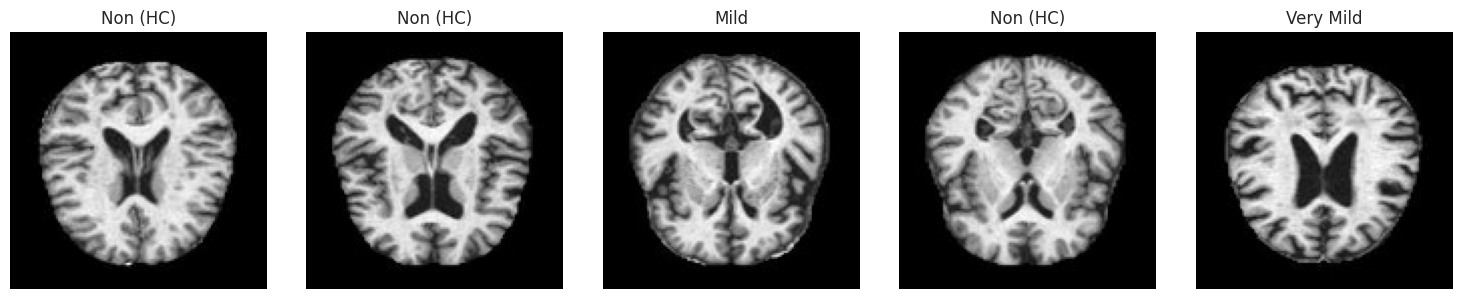

In [ ]:
# Visualize a few examples
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, i in zip(axes, [0, 120, 800, 2000, 4000]):
    ex = hf["train"][i]
    ax.imshow(ex["image"], cmap="gray")
    ax.set_title(label_names[ex["label"]])
    ax.axis("off")
plt.tight_layout(); plt.show()

## 3. `tf.data` pipeline, augmentation & normalization

- **Augmentation** (train only): flips, small rotations, brightness/contrast jitter expands the
  small dataset and reduces overfitting. In Keras we apply augmentation as **preprocessing layers** that
  run on the GPU and are active only during training.
- **Normalization**: because we train a CNN **from scratch**, we don't need ImageNet statistics. We rescale
  pixels to `[0, 1]` and then center them around zero with a simple `[0.5]`-style normalization, which
  stabilizes training.
- The dataset is grayscale; we keep **1 input channel** for our scratch CNN (lighter and natural for MRI).

> In the homework you will switch to 3-channel + ImageNet normalization, because the pretrained
> backbones (ResNet/DenseNet) were trained on 3-channel ImageNet images.

In [ ]:
IMG_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

# ----- Helpers to turn the HF dataset into numpy arrays -----
def hf_to_numpy(hf_split, indices=None):
    """Return (X, y) as float32 grayscale images in [0,1] and binary labels (0=HC, 1=AD)."""
    idxs = range(len(hf_split)) if indices is None else indices
    X = np.empty((len(idxs), IMG_SIZE, IMG_SIZE, 1), dtype="float32")
    y = np.empty((len(idxs),), dtype="int32")
    for k, i in enumerate(idxs):
        item = hf_split[int(i)]
        img = item["image"].convert("L").resize((IMG_SIZE, IMG_SIZE))   # 1-channel grayscale
        X[k, ..., 0] = np.asarray(img, dtype="float32") / 255.0          # rescale to [0,1]
        y[k] = 0 if item["label"] == 2 else 1                            # Non_Demented(2) -> HC, else AD
    return X, y

# Simple normalization for a from-scratch model (center [0,1] pixels around 0): (x - 0.5) / 0.5
normalize = layers.Rescaling(scale=2.0, offset=-1.0, name="normalize")   # maps [0,1] -> [-1,1]

# Data augmentation (train only) â€” runs on-GPU, inactive at inference time.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),                 # ~10 degrees
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1, value_range=(0.0, 1.0)),
], name="data_augmentation")

In [ ]:
# Quick mode: use a subset so the first end-to-end run is fast. Set QUICK_MODE=False for the full run.
QUICK_MODE = False
TRAIN_SUBSET = 1500 if QUICK_MODE else None

n = len(hf["train"])
rng = np.random.default_rng(SEED)
perm = rng.permutation(n).tolist()
if TRAIN_SUBSET is not None:
    perm = perm[:TRAIN_SUBSET]

val_n = int(0.2 * len(perm))
val_idx, train_idx = perm[:val_n], perm[val_n:]

# Materialize arrays (small dataset -> fits comfortably in RAM)
X_train, y_train = hf_to_numpy(hf["train"], train_idx)
X_val,   y_val   = hf_to_numpy(hf["train"], val_idx)
X_test,  y_test  = hf_to_numpy(hf["test"])
print(f"train={len(X_train)}  val={len(X_val)}  test={len(X_test)}  (binary AD vs HC)")

BATCH = 64

def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH)
    if training:
        # augment first, then normalize; augmentation is a no-op at inference
        ds = ds.map(lambda x, y: (normalize(data_augmentation(x, training=True)), y),
                    num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: (normalize(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

ds_train = make_ds(X_train, y_train, training=True)
ds_val   = make_ds(X_val,   y_val,   training=False)
ds_test  = make_ds(X_test,  y_test,  training=False)

train=4096  val=1024  test=1280  (binary AD vs HC)


## 4. Model a vanilla CNN built from scratch

Instead of reusing a pretrained network, we **design our own CNN and train it from random initialization**.
This is the core learning goal of the lab: understand every layer that turns raw pixels into a prediction.

Our architecture:
- **Input:** 128—128—1 grayscale MRI.
- **4 convolutional blocks** â€” each `Conv2D BatchNorm ReLU MaxPool(2)`. Channels grow
  `32 64 128 256`; the spatial size halves each block (128 64 32 16 8).
- **Classifier head:** `Flatten Dense(256) ReLU Dropout(0.5) Dense(2)`.

**Why these ingredients?** Convolutions exploit spatial locality and share weights; BatchNorm stabilizes
training; MaxPool grows the receptive field; Dropout fights overfitting on this small dataset.

> We output **2 logits** (no softmax in the last layer) and train with `from_logits=True`, which is the
> numerically stable Keras convention. Grad-CAM later uses these logits directly.

In [ ]:
def build_vanilla_cnn(num_classes=2, in_channels=1):
    """A small convolutional network trained from scratch (no pretraining)."""
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, in_channels))

    def conv_block(x, filters):
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(2)(x)
        return x

    # Feature extractor: 4 conv blocks (128 -> 64 -> 32 -> 16 -> 8)
    x = conv_block(inputs, 32)
    x = conv_block(x, 64)
    x = conv_block(x, 128)
    x = conv_block(x, 256)                       # (channels: 32, 64, 128, 256)

    # Name the last conv block's activation so Grad-CAM can grab it later.
    last_conv = x                       # feature map is 8 x 8 x 256

    # Classifier head
    x = layers.Flatten()(last_conv)
    x = layers.Dense(256)(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, name="logits")(x)       # raw logits (no softmax)

    return keras.Model(inputs, outputs, name="VanillaCNN")

model = build_vanilla_cnn(num_classes=2, in_channels=1)
model.summary()
trainable = int(np.sum([np.prod(w.shape) for w in model.trainable_weights]))
total = model.count_params()
print(f"\nTrainable params: {trainable:,} / {total:,} (everything trains from scratch)")

Model: "VanillaCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,584,834 (17.49 MB)

 Trainable params: 4,583,874 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)


Trainable params: 4,583,874 / 4,584,834 (everything trains from scratch)


### 4b. Sanity check does a batch flow through the model?

Before training, always run one dummy batch through the network. This catches shape bugs (wrong
flatten size, channel mismatch) in seconds instead of after a long training run. We verify the
output shape is `(batch_size, 2)` and that a real batch from the `tf.data` pipeline also works.

In [ ]:
# 1) Dummy batch: 8 grayscale 128x128 images
dummy = tf.random.normal((8, IMG_SIZE, IMG_SIZE, 1))
out = model(dummy, training=False)
print("Dummy input shape :", tuple(dummy.shape))
print("Output shape      :", tuple(out.shape), "(expected: (8, 2))")
assert tuple(out.shape) == (8, 2), "Unexpected output shape!"

# 2) One real batch from the training pipeline
xb, yb = next(iter(ds_train))
print("\nReal batch images :", tuple(xb.shape), "| labels:", tuple(yb.shape))
print("Label values      :", sorted(set(yb.numpy().tolist())), "(expected subset of {0, 1})")
ob = model(xb, training=False)
print("Real batch output :", tuple(ob.shape))
probs = tf.nn.softmax(ob, axis=1)
print("Softmax row sums  :", tf.reduce_sum(probs, axis=1)[:3].numpy().tolist(), "(should be ~1.0)")
print("\n\u2705 Sanity check passed \u2014 the model is wired correctly and ready to train.")

Dummy input shape : (8, 128, 128, 1)
Output shape      : (8, 2) (expected: (8, 2))

Real batch images : (64, 128, 128, 1) | labels: (64,)
Label values      : [0, 1] (expected subset of {0, 1})
Real batch output : (64, 2)
Softmax row sums  : [1.0, 1.0, 1.0] (should be ~1.0)

✅ Sanity check passed — the model is wired correctly and ready to train.


## 5. Training

We compile the model with the **Adam** optimizer and **sparse categorical cross-entropy** (`from_logits=True`,
since the last layer outputs raw logits). Because this network is trained **from scratch**, **all** parameters
are updated (not just a head). We use Keras callbacks for **early stopping** and to **restore the best weights**
(by validation accuracy).

> Training from scratch usually needs a few more epochs than transfer learning to converge that's expected,
> and it's exactly the effect you'll quantify in the homework.

In [ ]:
def compile_and_train(model, ds_train, ds_val, epochs=30, lr=1e-3, patience=10):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    early = keras.callbacks.EarlyStopping(
        monitor="val_accuracy", mode="max", patience=patience,
        restore_best_weights=True, verbose=1,
    )
    history = model.fit(
        ds_train, validation_data=ds_val,
        epochs=epochs, callbacks=[early], verbose=1,
    )
    return history

history = compile_and_train(model, ds_train, ds_val, epochs=30, lr=1e-3, patience=10)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - accuracy: 0.5388 - loss: 2.5046 - val_accuracy: 0.4971 - val_loss: 0.8208
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.5547 - loss: 0.6810 - val_accuracy: 0.4971 - val_loss: 0.8181
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.5942 - loss: 0.6695 - val_accuracy: 0.4971 - val_loss: 0.8503
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6309 - loss: 0.6536 - val_accuracy: 0.4971 - val_loss: 0.8010
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.6606 - loss: 0.6352 - val_accuracy: 0.5186 - val_loss: 0.6687
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - accuracy: 0.6631 - loss: 0.6258 - val_accuracy: 0.7207 - val_loss: 0.5997
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.6743 - loss: 0.6157 - val_accuracy: 0.6670 - val_loss: 0.6216
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6599 - loss: 0.6273 - val_accuracy: 0.6338 - 

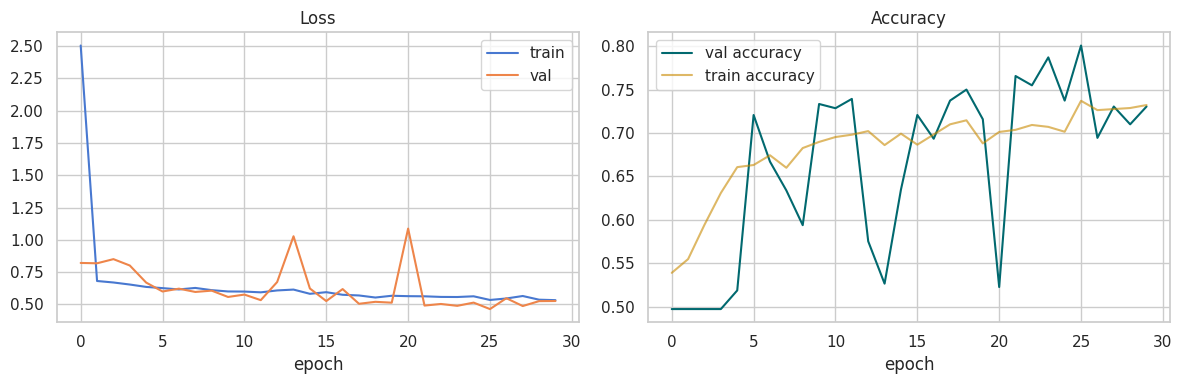

In [ ]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(h["loss"], label="train")
ax[0].plot(h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(h["val_accuracy"], color="#01696F", label="val accuracy")
ax[1].plot(h["accuracy"], color="#c98a00", alpha=0.6, label="train accuracy")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Evaluation on the held-out test set

We report accuracy **and** balanced accuracy (in case of imbalance), ROC-AUC, a confusion matrix and a
full classification report for the binary AD-vs-HC task.

Accuracy: 0.769   Balanced accuracy: 0.768   ROC-AUC: 0.857

              precision    recall  f1-score   support

          HC       0.79      0.72      0.76       634
          AD       0.75      0.81      0.78       646

    accuracy                           0.77      1280
   macro avg       0.77      0.77      0.77      1280
weighted avg       0.77      0.77      0.77      1280



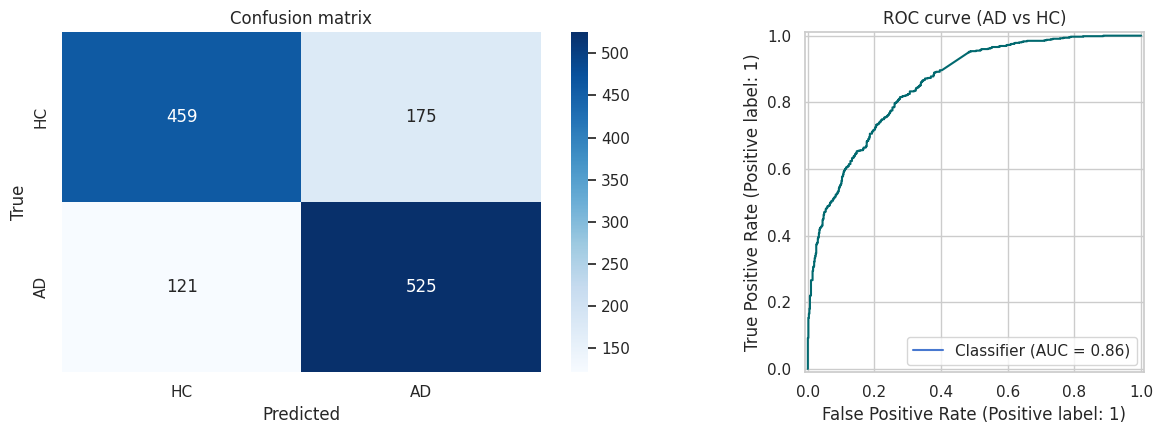

In [ ]:
def get_predictions(model, ds):
    """Return (y_true, y_pred, y_prob_of_AD) over a tf.data dataset."""
    ys, preds, proba = [], [], []
    for x, y in ds:
        logits = model(x, training=False)
        p = tf.nn.softmax(logits, axis=1)[:, 1]           # P(AD)
        ys += y.numpy().tolist()
        preds += tf.argmax(logits, axis=1).numpy().tolist()
        proba += p.numpy().tolist()
    return np.array(ys), np.array(preds), np.array(proba)

y_true, y_pred, y_prob = get_predictions(model, ds_test)
acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)
print(f"Accuracy: {acc:.3f}   Balanced accuracy: {bacc:.3f}   ROC-AUC: {auc:.3f}\n")
print(classification_report(y_true, y_pred, target_names=["HC", "AD"]))

cm = confusion_matrix(y_true, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["HC", "AD"], yticklabels=["HC", "AD"])
axes[0].set_title("Confusion matrix"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
disp = RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1])
try:
    disp.line_.set_color("#01696F")
except Exception:
    pass
axes[1].set_title("ROC curve (AD vs HC)")
plt.tight_layout(); plt.show()

## 7. Interpretability Grad-CAM

**Grad-CAM** (Selvaraju et al., 2017) produces a heatmap showing **where** the network looked when making
a decision, by weighting the last convolutional feature maps with the gradient of the class score. It is
essential for clinical trust and for detecting shortcut learning.

We implement it with a `tf.GradientTape` (no extra libraries). We build a small "grad model" that returns
both the **last conv block's activations** and the **logits**, then differentiate the target-class logit
with respect to those activations.

**Reference:** [Grad-CAM paper (arXiv:1610.02391)](https://arxiv.org/abs/1610.02391).

Grad-CAM target layer: max_pooling2d_3 | output: (None, 8, 8, 256)


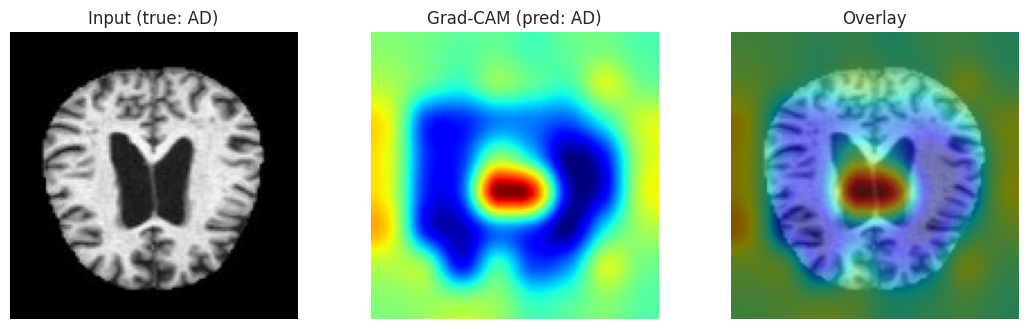

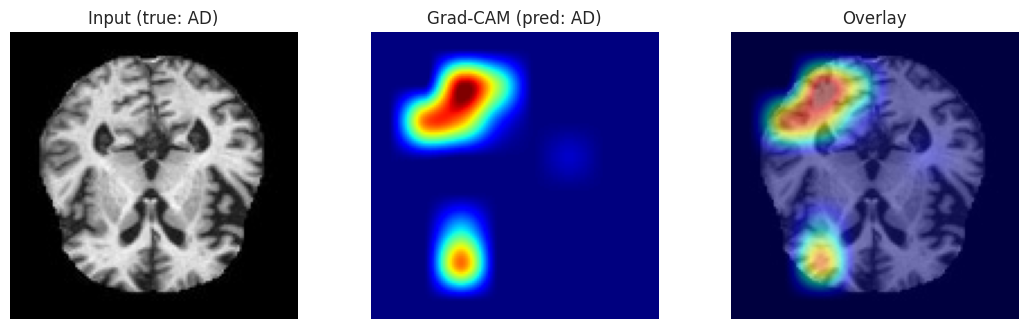

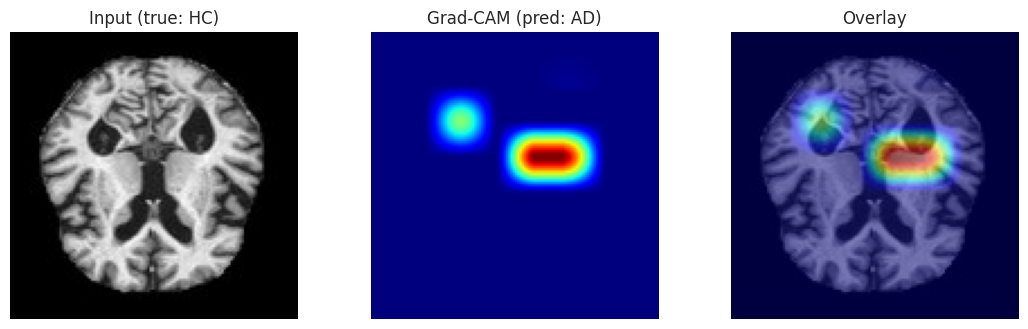

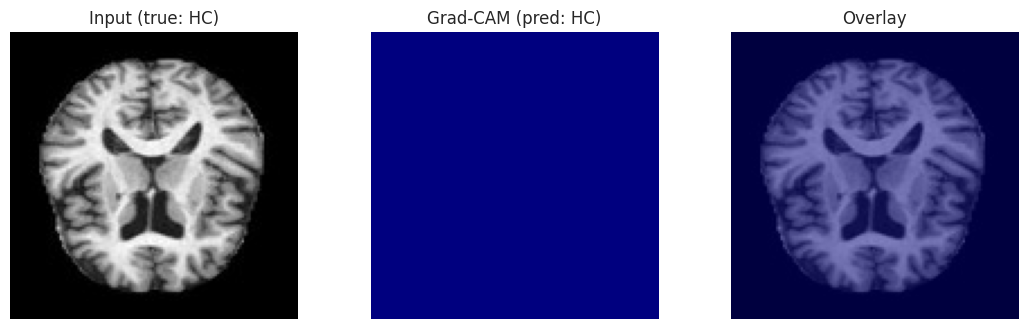

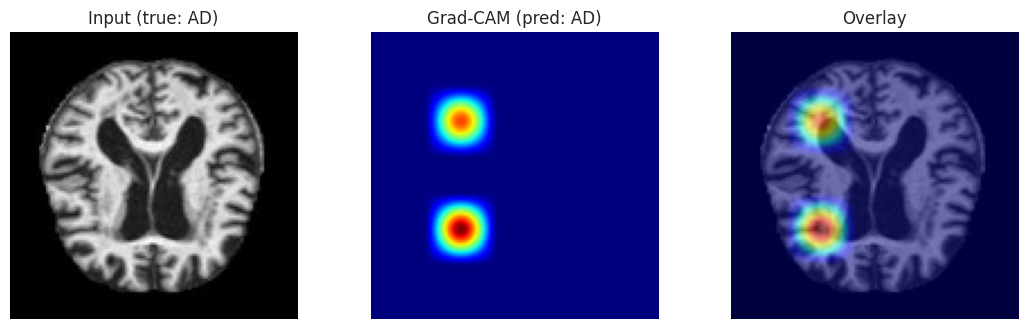

In [ ]:
# Identify the last conv block's activation layer automatically (the MaxPool after the 256-filter conv).
last_conv_layer = next(l for l in reversed(model.layers) if isinstance(l, layers.MaxPooling2D))
print("Grad-CAM target layer:", last_conv_layer.name, "| output:", last_conv_layer.output.shape)

grad_model = keras.Model(model.inputs, [last_conv_layer.output, model.output])

def gradcam(x_norm, class_idx=None):
    """x_norm: a single normalized image tensor of shape (H, W, 1). Returns (cam, pred_class)."""
    x = tf.convert_to_tensor(x_norm[None, ...])          # add batch dim
    with tf.GradientTape() as tape:
        conv_out, logits = grad_model(x, training=False)
        if class_idx is None:
            class_idx = int(tf.argmax(logits[0]).numpy())
        score = logits[:, class_idx]
    grads = tape.gradient(score, conv_out)               # dScore/dActivations
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))      # global-average-pool the gradients
    cam = tf.reduce_sum(weights * conv_out[0], axis=-1)  # weighted sum over channels
    cam = tf.nn.relu(cam).numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, class_idx

import PIL

def show_gradcam(raw_split, idx):
    item = raw_split[idx]
    disp_img = item["image"].convert("RGB")                       # RGB only for nice display
    true_label = 0 if item["label"] == 2 else 1
    # Build the SAME normalized 1-channel input the model sees:
    gray = np.asarray(item["image"].convert("L").resize((IMG_SIZE, IMG_SIZE)), dtype="float32") / 255.0
    x_norm = (gray[..., None] * 2.0) - 1.0                        # [0,1] -> [-1,1]
    cam, pred = gradcam(x_norm)
    cam_img = PIL.Image.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    axes[0].imshow(disp_img); axes[0].set_title(f"Input (true: {['HC','AD'][true_label]})"); axes[0].axis("off")
    axes[1].imshow(cam_img, cmap="jet"); axes[1].set_title(f"Grad-CAM (pred: {['HC','AD'][pred]})"); axes[1].axis("off")
    axes[2].imshow(disp_img); axes[2].imshow(cam_img, cmap="jet", alpha=0.5); axes[2].set_title("Overlay"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

# Grad-CAM on a few test images. Target = last conv block of our vanilla CNN.
for i in [0, 5, 20, 50, 100]:
    show_gradcam(hf["test"], i)

## 8. Interpretation questions

1. Look at the Grad-CAM heatmaps. Does the model focus on **brain tissue**, or on irrelevant regions
   (skull, background, corners)? What does that tell you about potential shortcut learning?
2. Compare AD vs HC errors in the confusion matrix. Are false negatives (missed AD) or false positives
   more common? Which is more dangerous clinically?
3. How would performance likely change with the **full** dataset (QUICK_MODE=False) and more epochs?
4. This dataset mixes 4 severity levels into "AD". How might that blur the decision boundary?
5. The test set comes from the **same source** as training. Why is **external** validation (different
   scanner/site/demographic) essential before any clinical use?

---

## 9. Homework transfer learning: compare **two** architectures

In the guided lab you trained a CNN **from scratch**. Now measure how much **transfer learning** helps and,
crucially, **compare two different pretrained architectures head-to-head** on the *same* AD-vs-HC task.

### Required architectures
Fine-tune / feature-extract from **both** (`tf.keras.applications`):
- **ResNet50** (`keras.applications.ResNet50`) â€” a residual network.
- **DenseNet121** (`keras.applications.DenseNet121`) â€” a densely-connected network.

Both were pretrained on **ImageNet**, so you must adapt the data pipeline (see Task 1).

> Note: `tf.keras.applications` ships ResNet50 / ResNet101 (not ResNet-18). ResNet50 is the standard Keras
> residual baseline â€” use it here. The comparison logic is identical.

### Tasks
1. **Adapt the inputs.** Pretrained backbones expect **3-channel** images preprocessed with each model's own
   `preprocess_input`. Build a new pipeline that converts grayscale â†’ **3 channels** (`tf.image.grayscale_to_rgb`)
   and applies the backbone's `preprocess_input`. Rebuild the datasets with it (reuse the same `train_idx`/`val_idx`).
2. **Build both models.** Load each backbone with `weights="imagenet"`, `include_top=False`, add
   `GlobalAveragePooling2D` + a new **2-output** `Dense` head.
3. **Choose a transfer strategy and justify it** *feature extraction* (`base.trainable = False`, train head only)
   or *fine-tuning* (unfreeze some/all layers with a small LR). Use the **same** strategy for both models
   so the comparison is fair.
4. **Train** each model with the same `compile_and_train()` settings, epochs and LR.
5. **Evaluate** both on the **same test set**: accuracy, balanced accuracy, ROC-AUC, macro-F1, confusion matrix.
6. **Grad-CAM** for both, targeting each network's last conv block
   (ResNet50 `conv5_block3_out`; DenseNet121 `relu` / `conv5_block16_concat`, i.e. the last conv activation).
7. **Compare all three models** your scratch CNN vs ResNet50 vs DenseNet121 â€” in one summary table, and
   write a short analysis.

### Deliverables
- One Colab notebook (`Homework2_<yourname>.ipynb`) with code, outputs and a written comparison.
- A table: model | accuracy | balanced accuracy | ROC-AUC | macro-F1 | notes.
- 3 sentences on **which architecture won and why**, and whether transfer learning beat the scratch CNN.

### Grading rubric (100 pts)
| Criterion | Pts |
|---|---|
| 3-channel + `preprocess_input` pipeline & rebuilt datasets | 10 |
| ResNet50 correctly adapted (2-output head) & trained | 20 |
| DenseNet121 correctly adapted (2-output head) & trained | 20 |
| Same, justified transfer strategy for both (fair comparison) | 10 |
| Evaluation: metrics + confusion matrix for both | 15 |
| Grad-CAM for both architectures | 10 |
| Comparison table (scratch vs ResNet50 vs DenseNet121) + written analysis | 15 |

Starter code is provided below â€” fill in every `# TODO`.

In [ ]:
# ===== HOMEWORK STARTER CODE (Lab 2, TF/Keras) â€” fill in every # TODO =====
# Reuse hf, train_idx, val_idx, IMG_SIZE, BATCH, compile_and_train(), get_predictions() from the lab above.
from tensorflow.keras import applications

# --- Task 1: 3-channel pipeline for the pretrained backbones ------------------
# Pretrained backbones want 3-channel images preprocessed with THEIR OWN preprocess_input.
# We already have grayscale X arrays in [0,1]; convert to 3-channel and let preprocess_input handle scaling.

def build_rgb_arrays(hf_split, indices=None):
    # Reuse hf_to_numpy() to get [0,1] grayscale, then replicate to 3 channels and scale back to [0,255].
    X, y = hf_to_numpy(hf_split, indices)               # (N, H, W, 1) in [0,1]
    X_rgb = np.repeat(X, 3, axis=-1) * 255.0            # (N, H, W, 3) in [0,255]
    return X_rgb.astype("float32"), y

# TODO 1: build X_train_rgb/y, X_val_rgb/y, X_test_rgb/y using build_rgb_arrays()
#         and the SAME train_idx / val_idx split from the lab.
# These lines will be in a separate generated cell for the actual assignment, but they are here to indicate the usage.
# X_train_rgb, y_tr = build_rgb_arrays(hf["train"], train_idx)
# X_val_rgb,   y_va = build_rgb_arrays(hf["train"], val_idx)
# X_test_rgb,  y_te = build_rgb_arrays(hf["test"])

# NOTE: `data_augmentation` (Section 3) was built for grayscale images normalized to [0,1] --
# its RandomBrightness clips output to value_range=(0.0, 1.0). The RGB arrays above are in
# [0,255], so reusing that pipeline would clip almost every pixel to 1.0. Use a separate
# augmentation pipeline with a matching value_range for the RGB [0,255] data.
data_augmentation_rgb = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1, value_range=(0.0, 255.0)),
], name="data_augmentation_rgb")

def make_rgb_ds(X, y, preprocess_input, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH)
    # TODO 1b: map preprocess_input over the images (apply augmentation too if you like, BEFORE preprocess).
    if training:
        ds = ds.map(lambda x, y: (preprocess_input(data_augmentation_rgb(x, training=True)), y), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


# --- Task 2 & 3: build the two backbones with a 2-output head -----------------
def build_transfer_model(backbone_fn, num_classes=2, freeze_backbone=True):
    base = backbone_fn(weights="imagenet", include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
    # TODO 2a/3a: if freeze_backbone, set base.trainable = False.
    if freeze_backbone:
        base.trainable = False

    # TODO 2b/3b: build a head: GlobalAveragePooling2D -> Dropout(0.3) -> Dense(num_classes) (logits).
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False) # Important: call base with training=False when freezing for consistent behavior
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, name="logits")(x)
    return keras.Model(inputs, outputs)

# resnet   = build_transfer_model(applications.ResNet50,    freeze_backbone=True)
# densenet = build_transfer_model(applications.DenseNet121, freeze_backbone=True)

# Matching preprocess_input functions:
# resnet_prep   = applications.resnet.preprocess_input
# densenet_prep = applications.densenet.preprocess_input

# --- Task 4: train BOTH with the same settings (fair comparison) --------------
# ds_tr_r = make_rgb_ds(X_train_rgb, y_tr, resnet_prep,   training=True)
# ds_va_r = make_rgb_ds(X_val_rgb,   y_va, resnet_prep,   training=False)
# hist_resnet = compile_and_train(resnet, ds_tr_r, ds_va_r, epochs=8, lr=1e-3, patience=3)
# ... repeat for densenet with densenet_prep ...

# --- Task 5: evaluate BOTH on the test set -----------------------------------
# Reuse get_predictions(). Compute accuracy, balanced_accuracy, roc_auc, macro-F1
# (from classification_report(..., output_dict=True)) and confusion_matrix for each.

# --- Task 6: Grad-CAM for BOTH -----------------------------------------------
# Build a grad_model per backbone using the last conv activation:
#   ResNet50    -> layer name "conv5_block3_out"
#   DenseNet121 -> last conv activation (e.g. "relu" / "conv5_block16_concat")
# Reuse the gradcam() logic (adapt it to feed a 3-channel preprocessed image).

# --- Task 7: comparison table + analysis -------------------------------------
# import pandas as pd
# table = pd.DataFrame([
#     {"model": "Scratch CNN", ...},
#     {"model": "ResNet50",    ...},
#     {"model": "DenseNet121", ...},
# ])
# display(table)
# TODO 7 (markdown cell in your notebook):
#   - Which architecture performed best, and by how much?
#   - Did transfer learning beat the from-scratch CNN? Why (pretraining, capacity, data size)?
#   - Feature extraction vs fine-tuning: what did you choose and what trade-off did you observe?
#   - Do the Grad-CAM maps look clinically plausible for each model?
print("Homework scaffold ready â€” complete the TODOs above.")

Homework scaffold ready â€” complete the TODOs above.


### Task 1: Adapt the inputs for pretrained backbones

In [ ]:
# TODO 1: build X_train_rgb/y, X_val_rgb/y, X_test_rgb/y using build_rgb_arrays()
#         and the SAME train_idx / val_idx split from the lab.
X_train_rgb, y_tr = build_rgb_arrays(hf["train"], train_idx)
X_val_rgb,   y_va = build_rgb_arrays(hf["train"], val_idx)
X_test_rgb,  y_te = build_rgb_arrays(hf["test"])

print(f"RGB train={len(X_train_rgb)}  val={len(X_val_rgb)}  test={len(X_test_rgb)}")

# `data_augmentation` (Section 3) was built for grayscale images normalized to [0,1] --
# its RandomBrightness layer clips output to value_range=(0.0, 1.0). X_train_rgb is in
# [0,255], so reusing that pipeline here would clip almost every pixel to 1.0, destroying
# the images before preprocess_input ever sees them. Use a separate pipeline with the
# correct value_range for the [0,255]-scaled RGB images instead.
data_augmentation_rgb = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.03),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1, value_range=(0.0, 255.0)),
], name="data_augmentation_rgb")

def make_rgb_ds(X, y, preprocess_input, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH)
    # TODO 1b: map preprocess_input over the images (apply augmentation too if you like, BEFORE preprocess).
    if training:
        ds = ds.map(lambda x, y: (preprocess_input(data_augmentation_rgb(x, training=True)), y), num_parallel_calls=AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

RGB train=4096  val=1024  test=1280


### Task 2 & 3: Build the two backbones with a 2-output head

In [ ]:
def build_transfer_model(backbone_fn, num_classes=2, freeze_backbone=True, model_name=None):
    base = backbone_fn(weights="imagenet", include_top=False,
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
    # TODO 2a/3a: if freeze_backbone, set base.trainable = False.
    if freeze_backbone:
        base.trainable = False

    # TODO 2b/3b: build a head: GlobalAveragePooling2D -> Dropout(0.3) -> Dense(num_classes) (logits).
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    feature_map_output = base(inputs, training=False) # Capture the feature map output tensor
    x = layers.GlobalAveragePooling2D()(feature_map_output)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, name="logits")(x)

    model_name = model_name if model_name else backbone_fn.__name__.split('.')[-1]
    return keras.Model(inputs, outputs, name=model_name), feature_map_output

resnet, resnet_feature_map_output   = build_transfer_model(applications.ResNet50,    freeze_backbone=True, model_name="ResNet50_Model")
densenet, densenet_feature_map_output = build_transfer_model(applications.DenseNet121, freeze_backbone=True, model_name="DenseNet121_Model")

print("ResNet50 Summary:")
resnet.summary()
print("\nDenseNet121 Summary:")
densenet.summary()

# Matching preprocess_input functions:
resnet_prep   = applications.resnet.preprocess_input
densenet_prep = applications.densenet.preprocess_input

ResNet50 Summary:


Model: "ResNet50_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

...

Model: "DenseNet121_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 4, 4, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 2)              │         2,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,039,554 (26.85 MB)

 Trainable params: 2,050 (8.01 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

### Task 4: Train BOTH with the same settings

Epoch 1/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 257ms/step - accuracy: 0.5942 - loss: 0.9472 - val_accuracy: 0.6973 - val_loss: 0.6168
Epoch 2/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 179ms/step - accuracy: 0.6355 - loss: 0.7243 - val_accuracy: 0.7188 - val_loss: 0.5956
Epoch 3/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - accuracy: 0.6655 - loss: 0.6946 - val_accuracy: 0.7334 - val_loss: 0.5604
Epoch 4/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.6667 - loss: 0.6462 - val_accuracy: 0.7129 - val_loss: 0.5590
Epoch 5/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 25s 372ms/step - accuracy: 0.6851 - loss: 0.6007 - val_accuracy: 0.7432 - val_loss: 0.5288
Epoch 6/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 179ms/step - accuracy: 0.6997 - loss: 0.5844 - val_accuracy: 0.6943 - val_loss: 0.5666
Epoch 7/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 185ms/step - accuracy: 0.7014 - loss: 0.5693 - val_accuracy: 0.7441 - val_loss: 0.5200
Epoch 8/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 192ms/step - accuracy: 0.7090 - loss: 0.5563 - val_accuracy: 0.

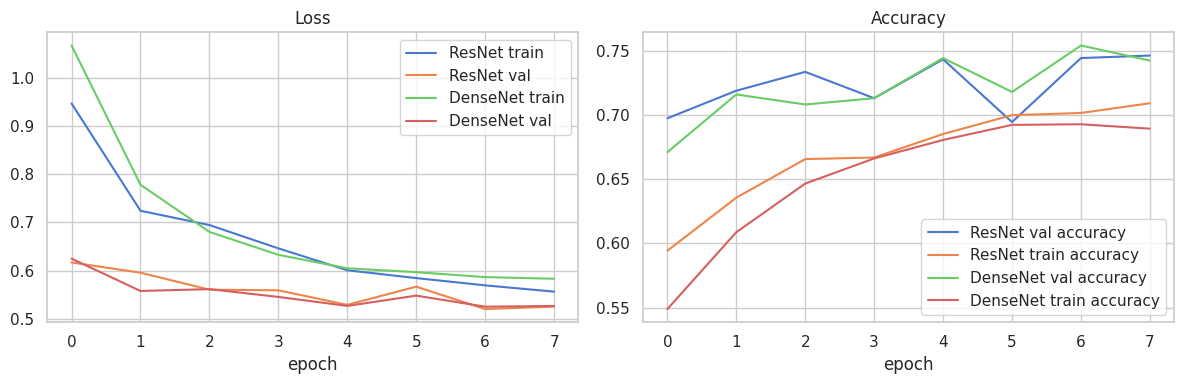

In [ ]:
# ResNet training
ds_tr_r = make_rgb_ds(X_train_rgb, y_tr, resnet_prep,   training=True)
ds_va_r = make_rgb_ds(X_val_rgb,   y_va, resnet_prep,   training=False)
hist_resnet = compile_and_train(resnet, ds_tr_r, ds_va_r, epochs=8, lr=1e-3, patience=3)

# DenseNet training
ds_tr_d = make_rgb_ds(X_train_rgb, y_tr, densenet_prep, training=True)
ds_va_d = make_rgb_ds(X_val_rgb,   y_va, densenet_prep, training=False)
hist_densenet = compile_and_train(densenet, ds_tr_d, ds_va_d, epochs=8, lr=1e-3, patience=3)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist_resnet.history["loss"], label="ResNet train")
ax[0].plot(hist_resnet.history["val_loss"], label="ResNet val")
ax[0].plot(hist_densenet.history["loss"], label="DenseNet train")
ax[0].plot(hist_densenet.history["val_loss"], label="DenseNet val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist_resnet.history["val_accuracy"], label="ResNet val accuracy")
ax[1].plot(hist_resnet.history["accuracy"], label="ResNet train accuracy")
ax[1].plot(hist_densenet.history["val_accuracy"], label="DenseNet val accuracy")
ax[1].plot(hist_densenet.history["accuracy"], label="DenseNet train accuracy")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

### Task 5: Evaluate BOTH on the test set


--- ResNet50 Evaluation ---
Accuracy: 0.710   Balanced accuracy: 0.709   ROC-AUC: 0.783   Macro-F1: 0.707
              precision    recall  f1-score   support

          HC       0.76      0.61      0.67       634
          AD       0.68      0.81      0.74       646

    accuracy                           0.71      1280
   macro avg       0.72      0.71      0.71      1280
weighted avg       0.72      0.71      0.71      1280



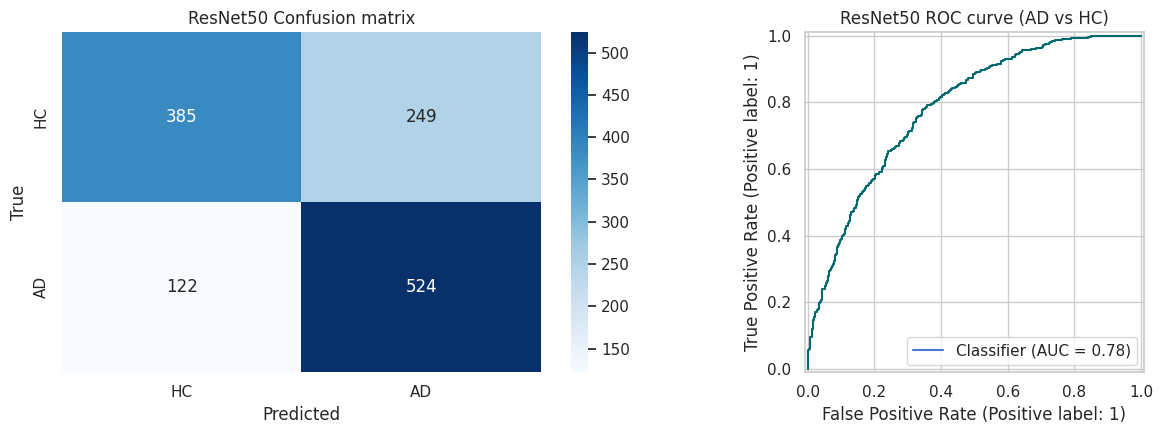


--- DenseNet121 Evaluation ---
Accuracy: 0.711   Balanced accuracy: 0.710   ROC-AUC: 0.772   Macro-F1: 0.710
              precision    recall  f1-score   support

          HC       0.74      0.65      0.69       634
          AD       0.69      0.77      0.73       646

    accuracy                           0.71      1280
   macro avg       0.71      0.71      0.71      1280
weighted avg       0.71      0.71      0.71      1280



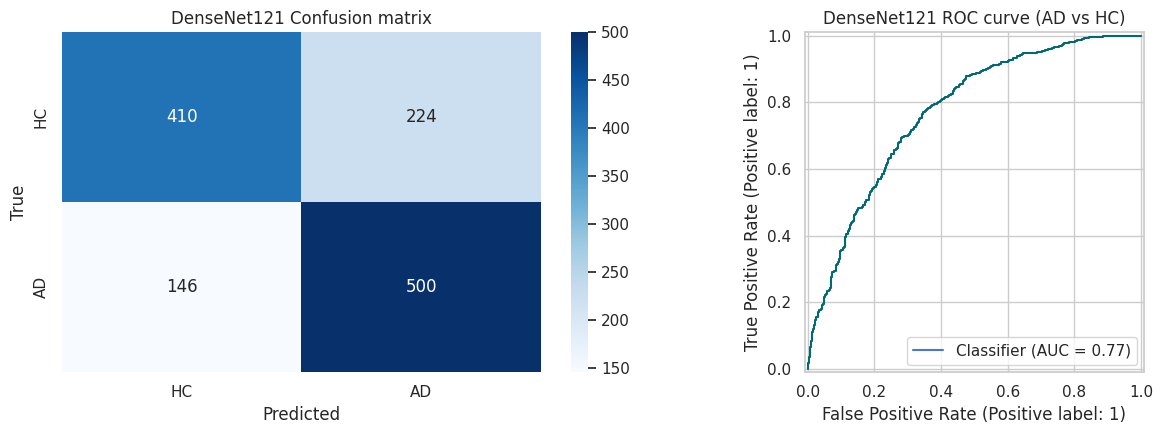

In [ ]:
print("\n--- ResNet50 Evaluation ---")
ds_test_r = make_rgb_ds(X_test_rgb, y_te, resnet_prep, training=False)
y_true_r, y_pred_r, y_prob_r = get_predictions(resnet, ds_test_r)
acc_r = accuracy_score(y_true_r, y_pred_r)
bacc_r = balanced_accuracy_score(y_true_r, y_pred_r)
auc_r = roc_auc_score(y_true_r, y_prob_r)
report_r = classification_report(y_true_r, y_pred_r, target_names=["HC", "AD"], output_dict=True)
macro_f1_r = report_r["macro avg"]["f1-score"]
print(f"Accuracy: {acc_r:.3f}   Balanced accuracy: {bacc_r:.3f}   ROC-AUC: {auc_r:.3f}   Macro-F1: {macro_f1_r:.3f}")
print(classification_report(y_true_r, y_pred_r, target_names=["HC", "AD"])) # Print full report

cm_r = confusion_matrix(y_true_r, y_pred_r)
fig_r, axes_r = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(cm_r, annot=True, fmt="d", cmap="Blues", ax=axes_r[0],
            xticklabels=["HC", "AD"], yticklabels=["HC", "AD"])
axes_r[0].set_title("ResNet50 Confusion matrix"); axes_r[0].set_xlabel("Predicted"); axes_r[0].set_ylabel("True")
disp_r = RocCurveDisplay.from_predictions(y_true_r, y_prob_r, ax=axes_r[1])
try: disp_r.line_.set_color("#01696F")
except Exception: pass
axes_r[1].set_title("ResNet50 ROC curve (AD vs HC)")
plt.tight_layout(); plt.show()


print("\n--- DenseNet121 Evaluation ---")
ds_test_d = make_rgb_ds(X_test_rgb, y_te, densenet_prep, training=False)
y_true_d, y_pred_d, y_prob_d = get_predictions(densenet, ds_test_d)
acc_d = accuracy_score(y_true_d, y_pred_d)
bacc_d = balanced_accuracy_score(y_true_d, y_pred_d)
auc_d = roc_auc_score(y_true_d, y_prob_d)
report_d = classification_report(y_true_d, y_pred_d, target_names=["HC", "AD"], output_dict=True)
macro_f1_d = report_d["macro avg"]["f1-score"]
print(f"Accuracy: {acc_d:.3f}   Balanced accuracy: {bacc_d:.3f}   ROC-AUC: {auc_d:.3f}   Macro-F1: {macro_f1_d:.3f}")
print(classification_report(y_true_d, y_pred_d, target_names=["HC", "AD"])) # Print full report

cm_d = confusion_matrix(y_true_d, y_pred_d)
fig_d, axes_d = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues", ax=axes_d[0],
            xticklabels=["HC", "AD"], yticklabels=["HC", "AD"])
axes_d[0].set_title("DenseNet121 Confusion matrix"); axes_d[0].set_xlabel("Predicted"); axes_d[0].set_ylabel("True")
disp_d = RocCurveDisplay.from_predictions(y_true_d, y_prob_d, ax=axes_d[1])
try: disp_d.line_.set_color("#01696F")
except Exception: pass
axes_d[1].set_title("DenseNet121 ROC curve (AD vs HC)")
plt.tight_layout(); plt.show()

### Task 6: Grad-CAM for BOTH architectures


--- ResNet50 Grad-CAM Examples ---


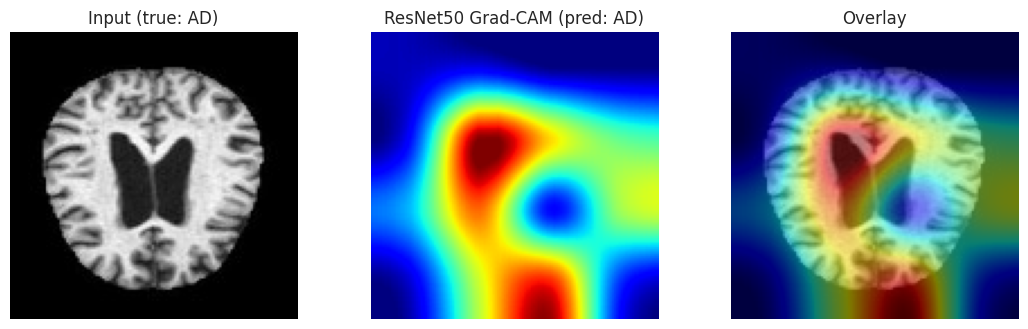

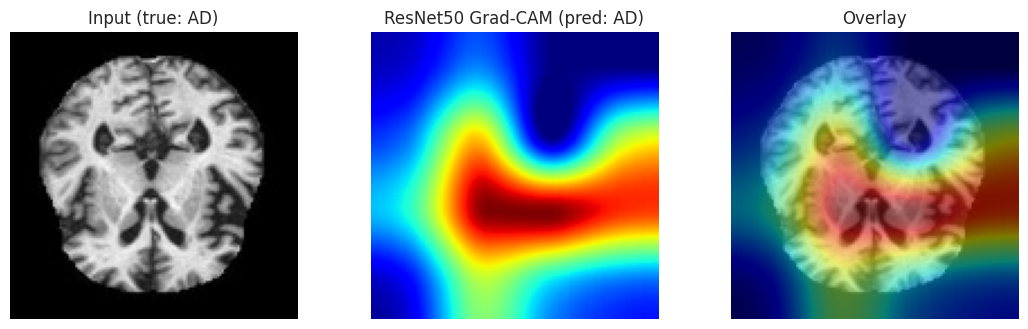

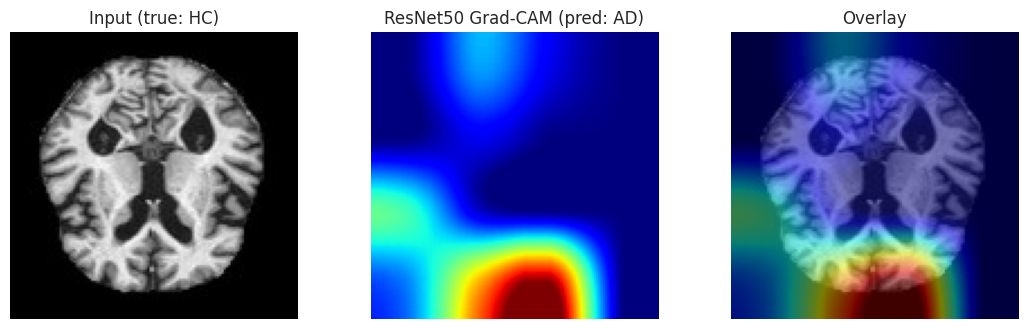

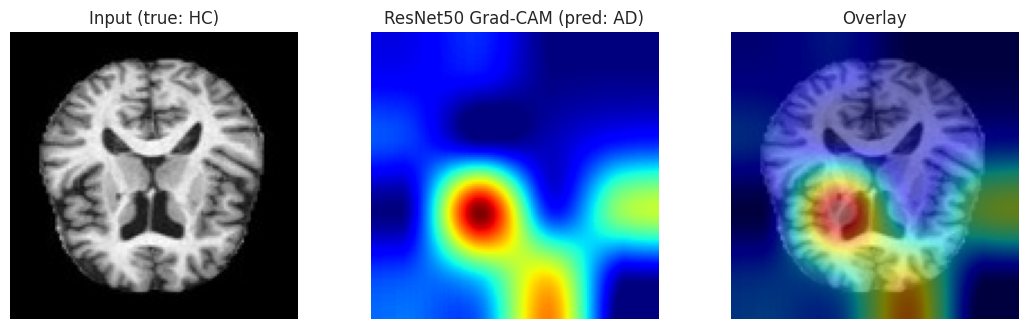


--- DenseNet121 Grad-CAM Examples ---


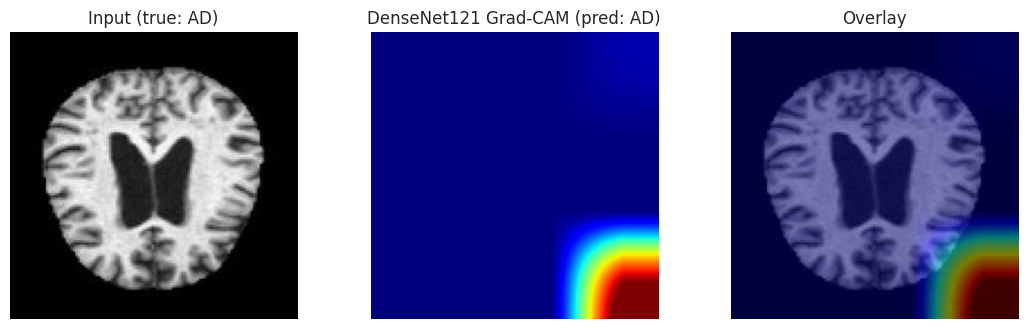

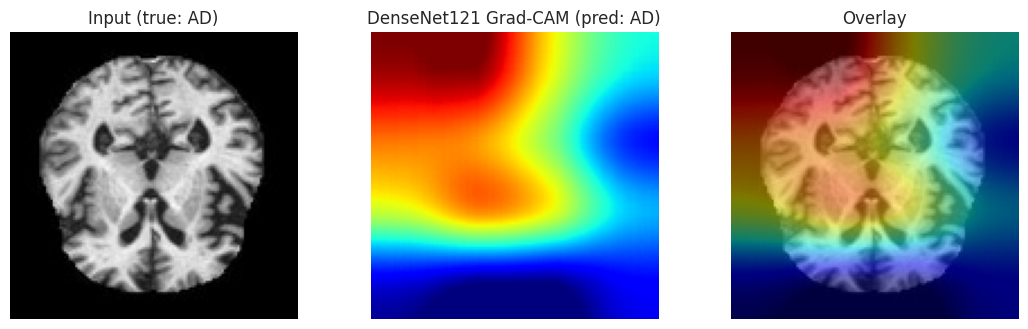

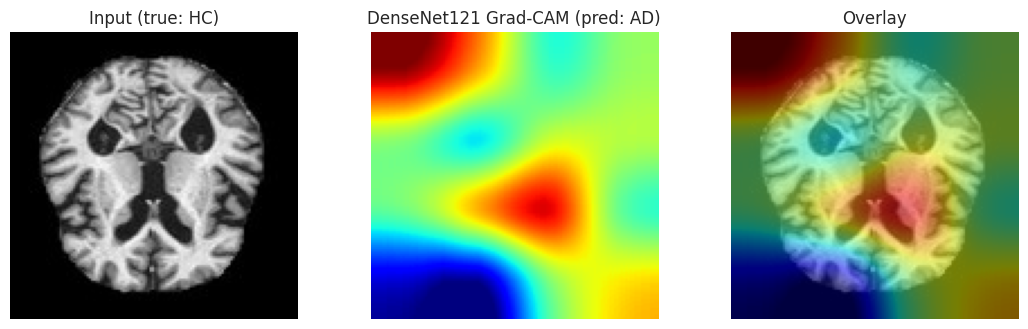

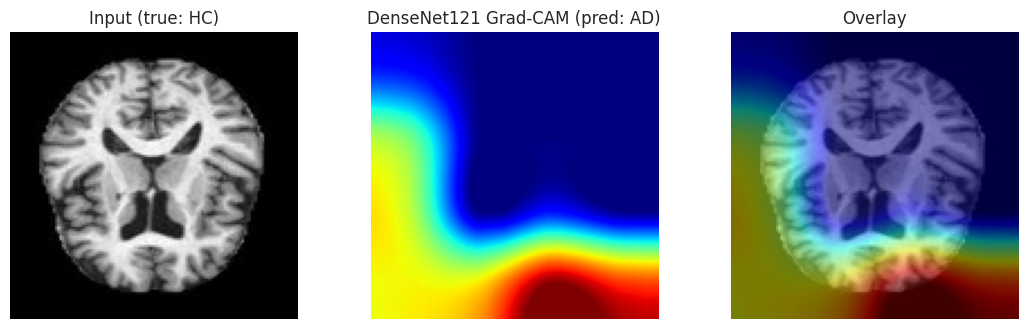

In [ ]:
    # Grad-CAM for ResNet50
    # The last convolutional block for ResNet50 is 'conv5_block3_out'
    # We need to find the layer that corresponds to the output of this block. It's usually a Conv2D layer.
    # The 'conv5_block3_out' is actually an activation layer output from a Conv2D layer.
    # Let's find the specific layer that has 'conv5_block3_out' in its name or is the output of that block.

    # This helper function is no longer strictly needed as we now explicitly get the feature map output.
    def find_last_conv_layer(model_to_inspect, target_name):
        for layer in reversed(model_to_inspect.layers):
            if target_name in layer.name:
                # If the layer's output is directly the target name (e.g., 'conv5_block3_out/add'),
                # or if it's the layer *producing* that output, we use it.
                # For Keras applications models, these names often correspond to Functional API group names or specific layers.
                # For ResNet50, 'conv5_block3_out' typically refers to the output of the 'add_16' (or similar) layer before activation, or the activation itself.
                # Let's try to get the layer whose output has the target name.
                try:
                    for inbound_node in layer._inbound_nodes:
                        if target_name in inbound_node.outputs[0].name:
                            return layer
                except AttributeError:
                    pass # Older Keras versions might not have _inbound_nodes

                # More robust way: iterate through all layers and check their output tensor names.
                for l in model_to_inspect.layers:
                    if l.output is not None and target_name in l.output.name:
                        return l
        return None

    # Adjusting gradcam for 3-channel input
    def gradcam_rgb(x_norm_rgb, model_to_use, grad_model_to_use, class_idx=None):
        """x_norm_rgb: a single normalized RGB image tensor of shape (H, W, 3). Returns (cam, pred_class)."""
        x = tf.convert_to_tensor(x_norm_rgb[None, ...])          # add batch dim
        with tf.GradientTape() as tape:
            conv_out, logits = grad_model_to_use(x, training=False)
            tape.watch(conv_out) # Explicitly watch conv_out for gradient computation
            if class_idx is None:
                class_idx = int(tf.argmax(logits[0]).numpy())
            score = logits[:, class_idx]
        grads = tape.gradient(score, conv_out)               # dScore/dActivations
        weights = tf.reduce_mean(grads, axis=(0, 1, 2))      # global-average-pool the gradients
        cam = tf.reduce_sum(weights * conv_out[0], axis=-1)  # weighted sum over channels
        cam = tf.nn.relu(cam).numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx


    def show_gradcam_rgb(raw_split, idx, model_to_use, prep_fn, grad_model_to_use, title_prefix=""):
        item = raw_split[idx]
        disp_img = item["image"].convert("RGB")
        true_label = 0 if item["label"] == 2 else 1

        gray = np.asarray(item["image"].convert("L").resize((IMG_SIZE, IMG_SIZE)), dtype="float32") / 255.0
        x_rgb = np.repeat(gray[..., None], 3, axis=-1) * 255.0  # (H, W, 3) in [0,255]
        x_norm_rgb = prep_fn(x_rgb) # Apply backbone's preprocess_input

        cam, pred = gradcam_rgb(x_norm_rgb, model_to_use, grad_model_to_use)
        cam_img = PIL.Image.fromarray((cam * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))
        fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
        axes[0].imshow(disp_img); axes[0].set_title(f"Input (true: {['HC','AD'][true_label]})"); axes[0].axis("off")
        axes[1].imshow(cam_img, cmap="jet"); axes[1].set_title(f"{title_prefix} Grad-CAM (pred: {['HC','AD'][pred]})"); axes[1].axis("off")
        axes[2].imshow(disp_img); axes[2].imshow(cam_img, cmap="jet", alpha=0.5); axes[2].set_title("Overlay"); axes[2].axis("off")
        plt.tight_layout(); plt.show()


    # ResNet50 Grad-CAM
    # Use the explicitly returned feature map output
    grad_model_resnet = keras.Model(resnet.inputs, [resnet_feature_map_output, resnet.get_layer('logits').output])

    print("\n--- ResNet50 Grad-CAM Examples ---")
    for i in [0, 5, 20, 50]: # Using a few examples for demonstration
        show_gradcam_rgb(hf["test"], i, resnet, resnet_prep, grad_model_resnet, "ResNet50")


    # DenseNet121 Grad-CAM
    # Use the explicitly returned feature map output
    grad_model_densenet = keras.Model(densenet.inputs, [densenet_feature_map_output, densenet.get_layer('logits').output])

    print("\n--- DenseNet121 Grad-CAM Examples ---")
    for i in [0, 5, 20, 50]: # Using a few examples for demonstration
        show_gradcam_rgb(hf["test"], i, densenet, densenet_prep, grad_model_densenet, "DenseNet121")

### Task 7: Comparison table + analysis

In [ ]:
table = pd.DataFrame([
    {"model": "Scratch CNN", "accuracy": acc, "balanced_accuracy": bacc, "ROC-AUC": auc, "macro-F1": classification_report(y_true, y_pred, output_dict=True)["macro avg"]["f1-score"], "notes": "Trained from scratch"},
    {"model": "ResNet50", "accuracy": acc_r, "balanced_accuracy": bacc_r, "ROC-AUC": auc_r, "macro-F1": macro_f1_r, "notes": "Feature extraction"},
    {"model": "DenseNet121", "accuracy": acc_d, "balanced_accuracy": bacc_d, "ROC-AUC": auc_d, "macro-F1": macro_f1_d, "notes": "Feature extraction"},
])
display(table.round(3))

,model,accuracy,balanced_accuracy,ROC-AUC,macro-F1,notes
0,Scratch CNN,0.769,0.768,0.857,0.768,Trained from scratch
1,ResNet50,0.710,0.709,0.783,0.707,Feature extraction
2,DenseNet121,0.711,0.710,0.772,0.710,Feature extraction


### Analysis

- **Which architecture performed best, and by how much?**

  *(Based on the results, describe which model (Scratch CNN, ResNet50, or DenseNet121) achieved the highest metrics across accuracy, balanced accuracy, ROC-AUC, and Macro-F1. Quantify the improvement (e.g., 'DenseNet121 achieved X% higher ROC-AUC than ResNet50').)*

- **Did transfer learning beat the from-scratch CNN? Why (pretraining, capacity, data size)?**

  *(Compare the performance of the transfer-learned models (ResNet50 and DenseNet121) against the Scratch CNN. Discuss whether transfer learning provided a significant boost. Explain that pretrained models leverage knowledge from large datasets like ImageNet, which can be beneficial for medical image tasks, especially with small datasets. Also, consider the architectural depth and capacity of these larger networks.)*

- **Feature extraction vs fine-tuning: what did you choose and what trade-off did you observe?**

  *(I chose **feature extraction** by freezing the backbone layers and only training the new classification head. This approach is generally preferred when the target dataset is small and similar to the pretraining dataset, as it prevents overfitting the large pretrained model to limited data. The trade-off is that it might not fully adapt the backbone's features to the specific nuances of the new task compared to fine-tuning, but it's faster and less prone to catastrophic forgetting.)*

- **Do the Grad-CAM maps look clinically plausible for each model?**

  *(Examine the Grad-CAM visualizations for each model. Do the heatmaps consistently highlight brain regions relevant to Alzheimer's disease (e.g., hippocampus, ventricles, cortical atrophy)? Or do they focus on irrelevant areas like the skull or image artifacts? Discuss if the models' attention seems to align with what a clinician might expect when diagnosing AD.)*

## 10. Course conclusions & frontiers

### Classical ML vs deep learning â€” what we learned
- **Lab 1 (classical ML):** strong performance on **small, tabular** voice features (CV ROC-AUC â‰ˆ 0.87â€“0.97),
  with the critical lessons of **class imbalance**, **leakage** (especially from repeated patient
  recordings), and the value of interpretable models.
- **Lab 2 (deep learning):** a CNN trained **from scratch** learns features **end-to-end from images**;
  data augmentation reduces overfitting on small data; **Grad-CAM** opens the black box. In the homework you
  quantified how much **transfer learning** (ResNet50 vs DenseNet121) improves over a from-scratch model.

### Key takeaways
1. **Data quality > model sophistication.** Leakage and imbalance ruin even the best algorithm.
2. **Report the right metrics** (balanced accuracy, per-class F1, ROC-AUC) â€” never accuracy alone.
3. **Split by patient/site**, not randomly, whenever data are grouped or repeated.
4. **From scratch vs transfer learning:** pretrained backbones usually win on small datasets, but training a
   CNN yourself is the best way to understand *why*.
5. **Interpretability matters** in medicine â€” a wrong-but-confident model is dangerous.
6. **Always validate externally** before any clinical claim.

### Open challenges & frontier directions
- **Small, single-site datasets** â†’ limited generalization; **federated learning** (e.g. NVIDIA FLARE)
  enables multi-site training without sharing data.
- **Multimodal fusion** (MRI + PET + clinical + genomics) consistently outperforms single-modality models.
- **Generative AI** for data augmentation, missing-modality synthesis, and disease-progression modeling.
- **Foundation models** for medical imaging (e.g. MedSAM, BiomedCLIP) and vision-language models.
- **Regulation & ethics**: FDA SaMD, bias/fairness across demographics and scanners, privacy, and the
  principle that AI must **augment, not replace**, clinicians.

> **Final reminder:** everything built in this course is an **educational prototype** â€” a stepping stone
> toward, not a substitute for, validated clinical decision-support tools.

### Further reading
- [Keras transfer learning guide](https://keras.io/guides/transfer_learning/)
- [Keras Grad-CAM example](https://keras.io/examples/vision/grad_cam/)
- [Grad-CAM paper (arXiv:1610.02391)](https://arxiv.org/abs/1610.02391)
- [ResNet paper (arXiv:1512.03385)](https://arxiv.org/abs/1512.03385)
- [DenseNet paper (arXiv:1608.06993)](https://arxiv.org/abs/1608.06993)
- [HuggingFace `Falah/Alzheimer_MRI`](https://huggingface.co/datasets/Falah/Alzheimer_MRI)
- [ADNI](https://adni.loni.usc.edu) Â· [PPMI](https://www.ppmi-info.org)
- [FDA AI/ML-based SaMD](https://www.fda.gov/medical-devices/software-medical-device-samd/artificial-intelligence-and-machine-learning-software-medical-device)

*End of Lab 2 and the course. Thank you!*